# 2. Segunda base de datos. PAMAP 2

## 2.1. Cargar datos

In [4]:
import pandas as pd
import os

In [6]:
pd.set_option("display.float_format", "{:.3f}".format)

In [8]:
from abc import ABC, abstractmethod

class AbstractDataLoader(ABC):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        self.src_path = src_path
        self.keys = keys
        self.file_extension = file_extension
        self.delimiter = delimiter     
        
    @abstractmethod
    def load_data(self):
        pass

    @abstractmethod
    def _is_valid_extension(self, file):
        pass

In [10]:
class DataLoader(AbstractDataLoader):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        super().__init__(src_path, keys, file_extension, delimiter)
        
    
    def load_data(self):
        dataframes = []
        for file in os.listdir(self.src_path):
            if self._is_valid_extension(file):  
                df = pd.read_csv(os.path.join(self.src_path, file), delimiter=self.delimiter, names=self.keys)
                df['subject_id'] = self._get_subject_id(file)
                dataframes.append(df)
        final_df = pd.concat(dataframes, ignore_index=True)
        return final_df

                
    def _is_valid_extension(self, file):
        return file.endswith(self.file_extension)

    def _get_subject_id(self, file):
        return file.split('.')[0]

In [12]:
src = "datasets/2_PAMAP2/PAMAP2_Dataset/Protocol/"
keys = [
    "timestamp",
    "activityID",
    "heart_rate_bpm",
    # IMU Hand (columns 4–20)
    "IMU_Hand_temperature",
    "IMU_Hand_acceleration_16g_x",
    "IMU_Hand_acceleration_16g_y",
    "IMU_Hand_acceleration_16g_z",
    "IMU_Hand_acceleration_6g_x",
    "IMU_Hand_acceleration_6g_y",
    "IMU_Hand_acceleration_6g_z",
    "IMU_Hand_gyroscope_x",
    "IMU_Hand_gyroscope_y",
    "IMU_Hand_gyroscope_z",
    "IMU_Hand_magnetometer_x",
    "IMU_Hand_magnetometer_y",
    "IMU_Hand_magnetometer_z",
    "IMU_Hand_orientation_1",
    "IMU_Hand_orientation_2",
    "IMU_Hand_orientation_3",
    "IMU_Hand_orientation_4",
    # IMU Chest (columns 21–37)
    "IMU_Chest_temperature",
    "IMU_Chest_acceleration_16g_x",
    "IMU_Chest_acceleration_16g_y",
    "IMU_Chest_acceleration_16g_z",
    "IMU_Chest_acceleration_6g_x",
    "IMU_Chest_acceleration_6g_y",
    "IMU_Chest_acceleration_6g_z",
    "IMU_Chest_gyroscope_x",
    "IMU_Chest_gyroscope_y",
    "IMU_Chest_gyroscope_z",
    "IMU_Chest_magnetometer_x",
    "IMU_Chest_magnetometer_y",
    "IMU_Chest_magnetometer_z",
    "IMU_Chest_orientation_1",
    "IMU_Chest_orientation_2",
    "IMU_Chest_orientation_3",
    "IMU_Chest_orientation_4",
    # IMU Ankle (columns 38–54)
    "IMU_Ankle_temperature",
    "IMU_Ankle_acceleration_16g_x",
    "IMU_Ankle_acceleration_16g_y",
    "IMU_Ankle_acceleration_16g_z",
    "IMU_Ankle_acceleration_6g_x",
    "IMU_Ankle_acceleration_6g_y",
    "IMU_Ankle_acceleration_6g_z",
    "IMU_Ankle_gyroscope_x",
    "IMU_Ankle_gyroscope_y",
    "IMU_Ankle_gyroscope_z",
    "IMU_Ankle_magnetometer_x",
    "IMU_Ankle_magnetometer_y",
    "IMU_Ankle_magnetometer_z",
    "IMU_Ankle_orientation_1",
    "IMU_Ankle_orientation_2",
    "IMU_Ankle_orientation_3",
    "IMU_Ankle_orientation_4"
]

file_extension = '.dat'
delimiter = r'\s+'
data_loader_pamap = DataLoader(src, keys, file_extension, delimiter)
pamap_data = data_loader_pamap.load_data()

pamap_data.shape

(2872533, 55)

## 2.2. Dimensiones y primeras 5 filas

In [14]:
pamap_data.shape

(2872533, 55)

Podemos observar que el dataset consta de:

1. **Características**: 55
2. **Ejemplos**: 2,872,533

In [16]:
pamap_data.head()

,timestamp,activityID,heart_rate_bpm,IMU_Hand_temperature,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_acceleration_6g_x,IMU_Hand_acceleration_6g_y,IMU_Hand_acceleration_6g_z,...,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z,IMU_Ankle_orientation_1,IMU_Ankle_orientation_2,IMU_Ankle_orientation_3,IMU_Ankle_orientation_4,subject_id
0,8.380,0,104.000,30.000,2.372,8.601,3.510,2.440,8.762,3.355,...,0.009,-0.018,-61.189,-38.960,-58.144,1.000,0.000,0.000,0.000,subject101
1,8.390,0,NaN,30.000,2.188,8.566,3.662,2.395,8.551,3.642,...,-0.005,0.000,-59.848,-38.892,-58.525,1.000,0.000,0.000,0.000,subject101
2,8.400,0,NaN,30.000,2.374,8.601,3.549,2.305,8.536,3.733,...,0.000,0.022,-60.736,-39.414,-58.400,1.000,0.000,0.000,0.000,subject101
3,8.410,0,NaN,30.000,2.075,8.529,3.660,2.335,8.536,3.733,...,-0.020,0.011,-60.409,-38.764,-58.396,1.000,0.000,0.000,0.000,subject101
4,8.420,0,NaN,30.000,2.229,8.831,3.700,2.231,8.597,3.763,...,-0.014,-0.003,-61.520,-39.388,-58.269,1.000,0.000,0.000,0.000,subject101


## 2.3. Identifica y elimina los datos ausentes

In [18]:
pamap_data.isnull().sum()

timestamp                             0
activityID                            0
heart_rate_bpm                  2610265
IMU_Hand_temperature              13141
IMU_Hand_acceleration_16g_x       13141
IMU_Hand_acceleration_16g_y       13141
IMU_Hand_acceleration_16g_z       13141
IMU_Hand_acceleration_6g_x        13141
IMU_Hand_acceleration_6g_y        13141
IMU_Hand_acceleration_6g_z        13141
IMU_Hand_gyroscope_x              13141
IMU_Hand_gyroscope_y              13141
IMU_Hand_gyroscope_z              13141
IMU_Hand_magnetometer_x           13141
IMU_Hand_magnetometer_y           13141
IMU_Hand_magnetometer_z           13141
IMU_Hand_orientation_1            13141
IMU_Hand_orientation_2            13141
IMU_Hand_orientation_3            13141
IMU_Hand_orientation_4            13141
IMU_Chest_temperature              3563
IMU_Chest_acceleration_16g_x       3563
IMU_Chest_acceleration_16g_y       3563
IMU_Chest_acceleration_16g_z       3563
IMU_Chest_acceleration_6g_x        3563


Vemos que la cantidad de valores faltantes varía, pero no de sensor a sensor, sino que hay grupos de sensores que tienen la misma cantidad de faltantes. Vemos que depende de la posicíon del cuerpo en la cual esté el sensor:

- **Heart rate**: 2,610,265
- **Mano**: 13,141
- **Pecho**: 3,563
- **Tobillo**: 11,749

<BarContainer object of 4 artists>

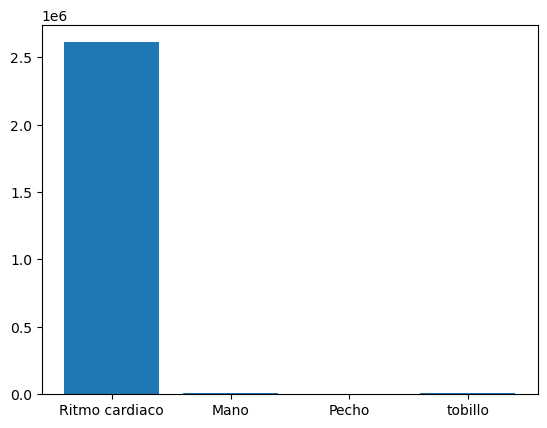

In [20]:
import matplotlib.pyplot as plt

# Datos
x = ["Ritmo cardiaco", "Mano", "Pecho", "tobillo"]
y = [2610265, 13141, 3563, 11749]

# Gráfico de barras
fig, ax = plt.subplots()
ax.bar(x = x, height = y)
# plt.show() 

Esto significa que tenemos muchos más valores faltantes en el monitor de ritmo cardíaco que en los demás, puesto que en este tenemos millones de vacíos. Mientras que en las manos y tobillo solo tenemos decenas de miles, y en el pecho solo unos cuantos miles. 

Si la proporción de valores faltantes en el heart rate monitor es demasiado alta, podríamos tener que eliminar la característica porque, si los reemplazamos, terminaremos muchas veces con el mismo valor (e.g. la media)

In [22]:
import pandas as pd

clases = ["Ritmo cardiaco", "Mano", "Pecho", "tobillo"]
faltantes = [2610265, 13141, 3563, 11749]
total = 2872533

ratios = [cantidad / total for cantidad in faltantes]
porcentajes = [ratio * 100 for ratio in ratios]

porcentaje_faltantes_por_clase = pd.DataFrame({
    'clase': clases,
    'cantidad de faltantes': faltantes,
    'ratio de faltantes': ratios,
    'porcentaje de faltantes': porcentajes
})

porcentaje_faltantes_por_clase

,clase,cantidad de faltantes,ratio de faltantes,porcentaje de faltantes
0,Ritmo cardiaco,2610265,0.909,90.870
1,Mano,13141,0.005,0.457
2,Pecho,3563,0.001,0.124
3,tobillo,11749,0.004,0.409


Podemos observar que 90% de los valores de ritmo cardíaco están vacíos, mentras que para la mano, el pecho y el tobillo, menos de un 1% de los valores son vacíos. Esto indica que, es posible, que un error haya ocurrido con el monitor de ritmo cardíaco o que la frecuencia de muestreo sea mucho menor. 

Si la frecuencia de muestro es menor, podríamos aplicar técnicas como el **forward propagation** o **interpolation**.

### 2.3.1. Heart rate monitor

Para determinar esto, nos vamos a la documentación. 

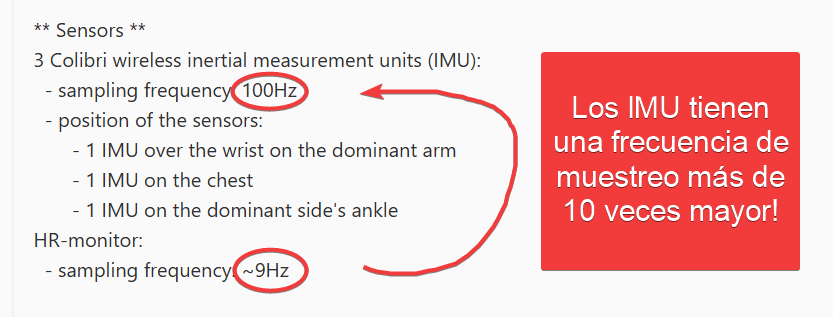


En ella notamos que el heart rate monitor tiene una frecuencia de muestreo de tan solo 9htz, mientras que los IMU tienen una de 100htz. Esto explica la razón detrás de que haya tantos valores faltantes: está tomando 10 veces menos mediciones. Esto es interesante porque significa que podríamos aplicar una de las técnicas mencionadas anteriormente (e.g. fill forward o interpolation), en lugar de eliminar la columna entera.

### 2.3.2. Linear interpolation

In [24]:
deep_copy_pamap = pamap_data.copy().infer_objects()

# Seleccionamos las columnas numéricas que se pueden interpolar, excluyendo 'subject_id'
cols_to_interpolate = deep_copy_pamap.select_dtypes(include="number").columns.drop("subject_id", errors="ignore")

# Aplicamos la interpolación lineal para cada columna numérica por grupo
for col in cols_to_interpolate:
    deep_copy_pamap[col] = deep_copy_pamap.groupby("subject_id")[col].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )

pamap_no_null = deep_copy_pamap.copy()
pamap_no_null.shape

(2872533, 55)

In [26]:
pamap_no_null.isnull().sum()

timestamp                       0
activityID                      0
heart_rate_bpm                  0
IMU_Hand_temperature            0
IMU_Hand_acceleration_16g_x     0
IMU_Hand_acceleration_16g_y     0
IMU_Hand_acceleration_16g_z     0
IMU_Hand_acceleration_6g_x      0
IMU_Hand_acceleration_6g_y      0
IMU_Hand_acceleration_6g_z      0
IMU_Hand_gyroscope_x            0
IMU_Hand_gyroscope_y            0
IMU_Hand_gyroscope_z            0
IMU_Hand_magnetometer_x         0
IMU_Hand_magnetometer_y         0
IMU_Hand_magnetometer_z         0
IMU_Hand_orientation_1          0
IMU_Hand_orientation_2          0
IMU_Hand_orientation_3          0
IMU_Hand_orientation_4          0
IMU_Chest_temperature           0
IMU_Chest_acceleration_16g_x    0
IMU_Chest_acceleration_16g_y    0
IMU_Chest_acceleration_16g_z    0
IMU_Chest_acceleration_6g_x     0
IMU_Chest_acceleration_6g_y     0
IMU_Chest_acceleration_6g_z     0
IMU_Chest_gyroscope_x           0
IMU_Chest_gyroscope_y           0
IMU_Chest_gyro

## 2.4. Tipos de datos de cada atributo

In [28]:
pamap_no_null.dtypes

timestamp                       float64
activityID                        int64
heart_rate_bpm                  float64
IMU_Hand_temperature            float64
IMU_Hand_acceleration_16g_x     float64
IMU_Hand_acceleration_16g_y     float64
IMU_Hand_acceleration_16g_z     float64
IMU_Hand_acceleration_6g_x      float64
IMU_Hand_acceleration_6g_y      float64
IMU_Hand_acceleration_6g_z      float64
IMU_Hand_gyroscope_x            float64
IMU_Hand_gyroscope_y            float64
IMU_Hand_gyroscope_z            float64
IMU_Hand_magnetometer_x         float64
IMU_Hand_magnetometer_y         float64
IMU_Hand_magnetometer_z         float64
IMU_Hand_orientation_1          float64
IMU_Hand_orientation_2          float64
IMU_Hand_orientation_3          float64
IMU_Hand_orientation_4          float64
IMU_Chest_temperature           float64
IMU_Chest_acceleration_16g_x    float64
IMU_Chest_acceleration_16g_y    float64
IMU_Chest_acceleration_16g_z    float64
IMU_Chest_acceleration_6g_x     float64


Observamos que todas las características son de tipo flotante excepto de "subject_id", la cual es una string y que en pandas se representa con el tipo object, y el "activityID" que es un entero.

## 2.5. Resumen estadístico

In [30]:
pamap_no_null.describe()

,timestamp,activityID,heart_rate_bpm,IMU_Hand_temperature,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_acceleration_6g_x,IMU_Hand_acceleration_6g_y,IMU_Hand_acceleration_6g_z,...,IMU_Ankle_gyroscope_x,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z,IMU_Ankle_orientation_1,IMU_Ankle_orientation_2,IMU_Ankle_orientation_3,IMU_Ankle_orientation_4
count,2872533.000,2872533.000,2872533.000,2872533.000,2872533.000,2872533.000,2872533.000,2872533.000,2872533.000,2872533.000,...,2872533.000,2872533.000,2872533.000,2872533.000,2872533.000,2872533.000,2872533.000,2872533.000,2872533.000,2872533.000
mean,1834.354,5.466,109.882,32.648,-4.971,3.588,3.165,-4.900,3.585,3.346,...,0.008,-0.034,0.007,-32.737,1.581,16.899,0.399,0.022,0.309,-0.019
std,1105.689,6.331,25.879,1.845,5.992,6.285,3.841,6.000,6.061,3.838,...,1.073,0.597,1.843,18.868,21.608,20.295,0.303,0.569,0.324,0.473
min,5.640,0.000,57.000,24.750,-145.367,-104.301,-101.452,-61.489,-61.868,-61.935,...,-23.995,-18.127,-14.020,-172.865,-137.908,-109.289,-0.254,-0.957,-0.877,-0.997
25%,893.160,0.000,90.000,31.438,-9.036,1.293,0.969,-8.939,1.287,1.164,...,-0.154,-0.083,-0.312,-42.903,-11.498,3.321,0.156,-0.584,0.011,-0.505
50%,1790.830,3.000,108.000,33.125,-5.806,3.572,2.955,-5.755,3.614,3.130,...,0.004,-0.004,-0.002,-33.922,1.336,18.096,0.320,0.000,0.305,0.000
75%,2710.570,7.000,125.455,34.000,-0.791,6.601,5.992,-0.734,6.601,6.244,...,0.095,0.083,0.064,-19.066,17.317,30.881,0.579,0.628,0.602,0.463
max,4475.630,24.000,202.000,35.500,62.860,155.699,157.760,52.821,62.260,61.945,...,17.420,13.588,16.529,97.525,123.306,146.900,1.000,0.960,0.992,0.996


## 2.6. Distribución de clases

In [32]:
class_distribution_pamap = pamap_no_null['activityID'].value_counts()
class_distribution_pamap

activityID
0     929661
4     238761
17    238690
1     192523
3     189931
7     188107
2     185188
16    175353
6     164600
12    117216
13    104944
5      98199
24     49360
Name: count, dtype: int64

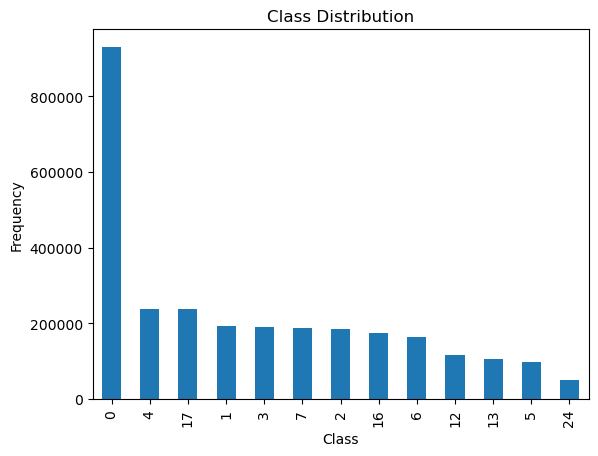

In [34]:
import matplotlib.pyplot as plt

class_distribution_pamap = pamap_data['activityID'].value_counts()
class_distribution_pamap.plot(kind='bar') 
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.title('Class Distribution')
plt.show()

Observamos que existe un imbalance de clases

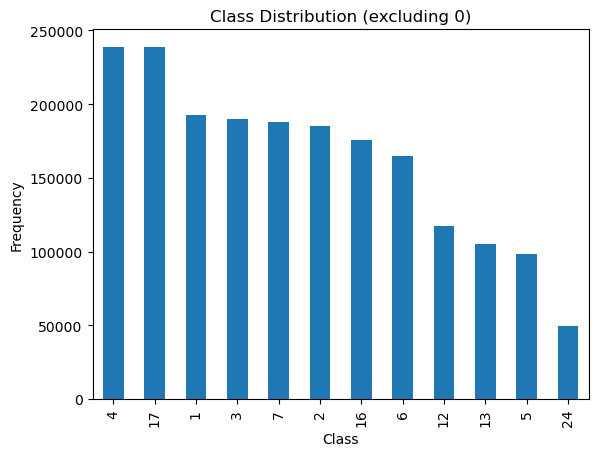

In [36]:
import matplotlib.pyplot as plt

# Filter out rows where 'activityID' is 0, then count the remaining classes
pamap_filtered_counts = pamap_data[pamap_data['activityID'] != 0]['activityID'].value_counts()

# Plot the resulting distribution
pamap_filtered_counts.plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.title('Class Distribution (excluding 0)')
plt.show()

Notamos un imbalance de clases en donde la clase menor es la clase 24. Tiene casi 4 veces menos que la clase 4. Por esto tenemos que usar métricas como Macro Average para ver la clasificación general y F1-score para la clasificación por nivel.

## 2.7. Correlación entre atributos

In [38]:
import pandas as pd

# Suponiendo que 'pamap_no_null' es tu DataFrame original

# Eliminar las columnas 'activityID' y 'timestamp' si existen
pamap_filtered = pamap_no_null.drop(columns=['activityID', 'timestamp'], errors='ignore')

# Seleccionar solo las columnas numéricas restantes
pamap_numeric = pamap_filtered.select_dtypes(include=['number'])

# Calcular la matriz de correlación utilizando el método de Spearman
pamap_corr_matrix = pamap_numeric.corr(method='spearman')

# Mostrar la matriz de correlación
pamap_corr_matrix

,heart_rate_bpm,IMU_Hand_temperature,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_acceleration_6g_x,IMU_Hand_acceleration_6g_y,IMU_Hand_acceleration_6g_z,IMU_Hand_gyroscope_x,IMU_Hand_gyroscope_y,...,IMU_Ankle_gyroscope_x,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z,IMU_Ankle_orientation_1,IMU_Ankle_orientation_2,IMU_Ankle_orientation_3,IMU_Ankle_orientation_4
heart_rate_bpm,1.000,-0.362,-0.192,0.011,-0.220,-0.199,0.011,-0.226,-0.005,0.022,...,-0.030,0.032,-0.067,-0.325,-0.179,-0.094,0.343,0.014,-0.028,0.140
IMU_Hand_temperature,-0.362,1.000,-0.005,-0.028,0.017,0.011,-0.028,0.033,-0.015,-0.003,...,0.015,-0.011,0.031,0.090,0.079,0.149,-0.114,0.036,0.041,0.061
IMU_Hand_acceleration_16g_x,-0.192,-0.005,1.000,0.169,0.279,0.987,0.158,0.279,0.038,-0.049,...,0.053,-0.028,0.132,0.064,0.156,-0.024,-0.049,0.047,-0.074,-0.061
IMU_Hand_acceleration_16g_y,0.011,-0.028,0.169,1.000,-0.079,0.174,0.978,-0.086,0.071,0.011,...,0.008,-0.040,-0.014,-0.086,-0.054,0.072,0.049,-0.046,-0.165,-0.019
IMU_Hand_acceleration_16g_z,-0.220,0.017,0.279,-0.079,1.000,0.281,-0.086,0.983,-0.006,0.040,...,0.056,-0.043,0.073,0.108,0.086,-0.035,-0.074,0.025,-0.042,-0.064
IMU_Hand_acceleration_6g_x,-0.199,0.011,0.987,0.174,0.281,1.000,0.162,0.280,0.035,-0.035,...,0.054,-0.028,0.128,0.065,0.160,-0.021,-0.050,0.049,-0.073,-0.060
IMU_Hand_acceleration_6g_y,0.011,-0.028,0.158,0.978,-0.086,0.162,1.000,-0.086,0.030,0.012,...,0.007,-0.040,-0.011,-0.087,-0.054,0.072,0.050,-0.046,-0.166,-0.019
IMU_Hand_acceleration_6g_z,-0.226,0.033,0.279,-0.086,0.983,0.280,-0.086,1.000,-0.004,0.023,...,0.057,-0.044,0.075,0.109,0.090,-0.033,-0.076,0.026,-0.040,-0.063
IMU_Hand_gyroscope_x,-0.005,-0.015,0.038,0.071,-0.006,0.035,0.030,-0.004,1.000,-0.189,...,0.047,-0.023,0.133,0.022,-0.042,-0.002,-0.004,-0.022,-0.015,-0.008
IMU_Hand_gyroscope_y,0.022,-0.003,-0.049,0.011,0.040,-0.035,0.012,0.023,-0.189,1.000,...,0.073,0.015,0.020,0.004,-0.004,-0.020,0.000,0.003,-0.021,0.002


## 2.8. Histograma de atributos

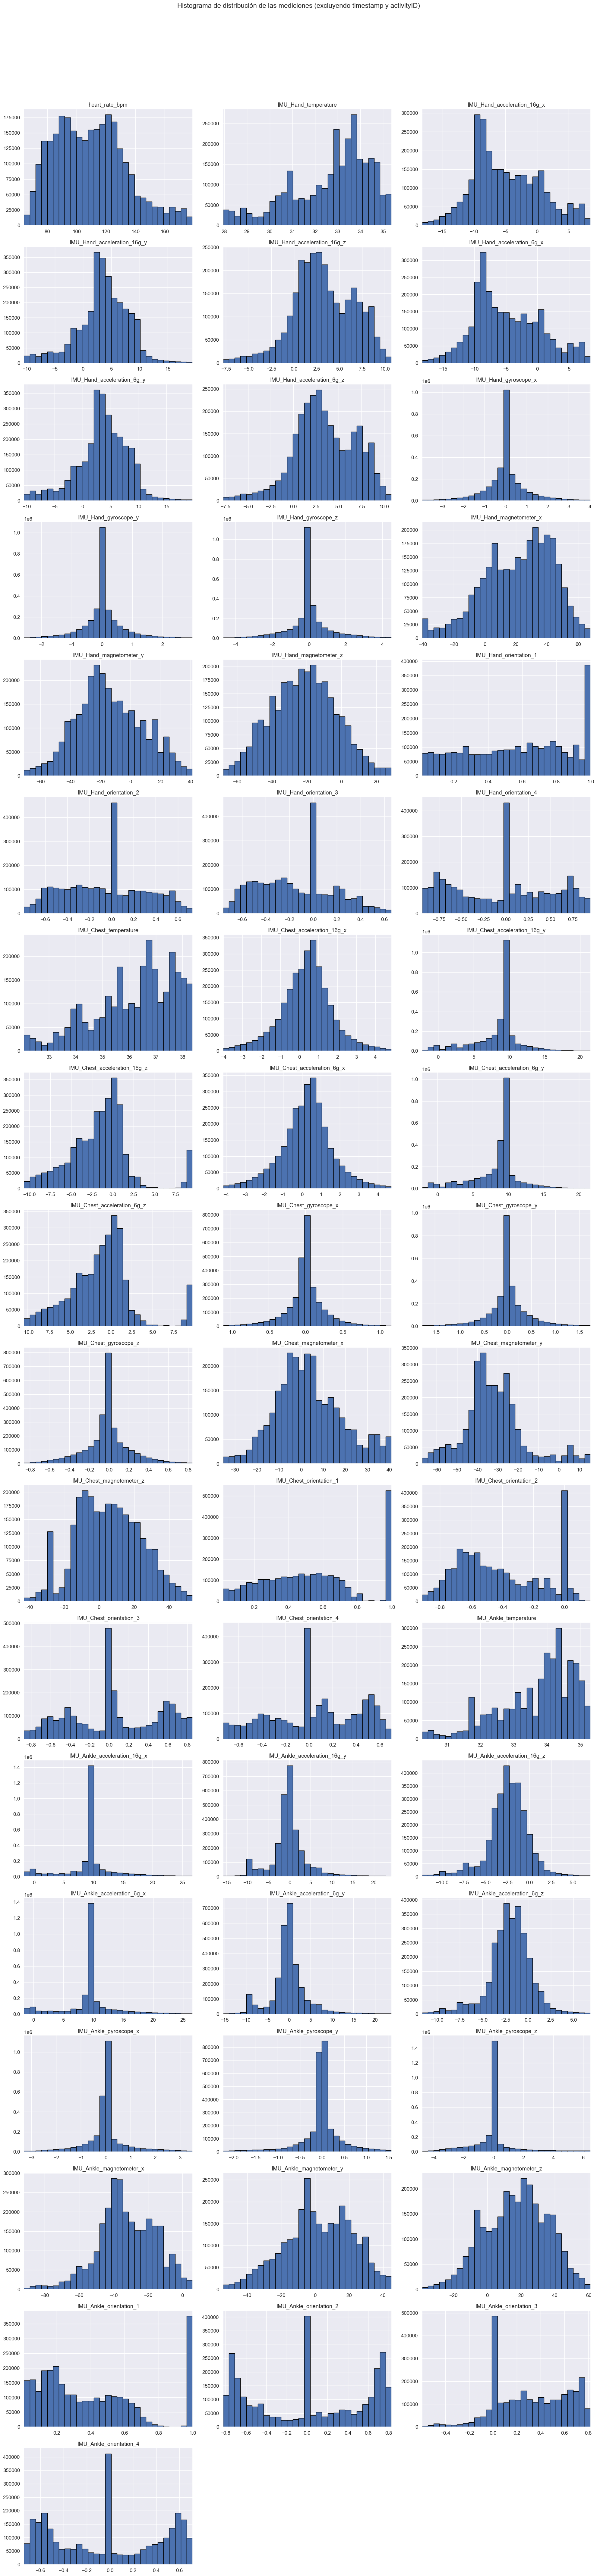

In [110]:
import numpy as np
import math
import matplotlib.pyplot as plt

# Lista de columnas que queremos excluir
excluded_cols = ['timestamp', 'activityID']

# Seleccionamos solo las columnas numéricas y excluimos 'timestamp' y 'activityID'
pamap_numeric = (
    pamap_no_null
    .select_dtypes(include=['number'])
    .drop(columns=excluded_cols, errors='ignore')
)

# Obtenemos la lista de columnas numéricas restantes
columns = pamap_numeric.columns
num_attributes = len(columns)

# Definimos el layout: máximo 3 columnas por fila
cols = 3
rows = math.ceil(num_attributes / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten()  # Para iterar fácilmente

for ax, col in zip(axes, columns):
    data = pamap_numeric[col].dropna()

    # Calculamos percentiles (por ejemplo, 1% y 99%)
    q1 = data.quantile(0.01)
    q99 = data.quantile(0.99)

    # Si el rango de valores en los percentiles es muy pequeño, evitamos errores
    if q1 == q99:
        ax.hist(data, bins=10, edgecolor='black')
        ax.set_title(col)
        ax.set_xlim([q1 - 1, q99 + 1])  # Ajuste mínimo para que no sea un rango vacío
        continue

    # Filtramos datos para el histograma (recortando outliers)
    data_filtered = data[(data >= q1) & (data <= q99)]

    # Generamos bins para ese rango filtrado
    bins = np.linspace(q1, q99, 30)

    # Graficamos solo los datos filtrados
    ax.hist(data_filtered, bins=bins, edgecolor='black')
    ax.set_title(col)

    # Ajustamos el límite de los ejes al rango filtrado
    ax.set_xlim([q1, q99])

# Si sobran ejes (subplots) porque hay menos columnas que subplots, los ocultamos
for ax in axes[num_attributes:]:
    ax.set_visible(False)

plt.suptitle("Histograma de distribución de las mediciones (excluyendo timestamp y activityID)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


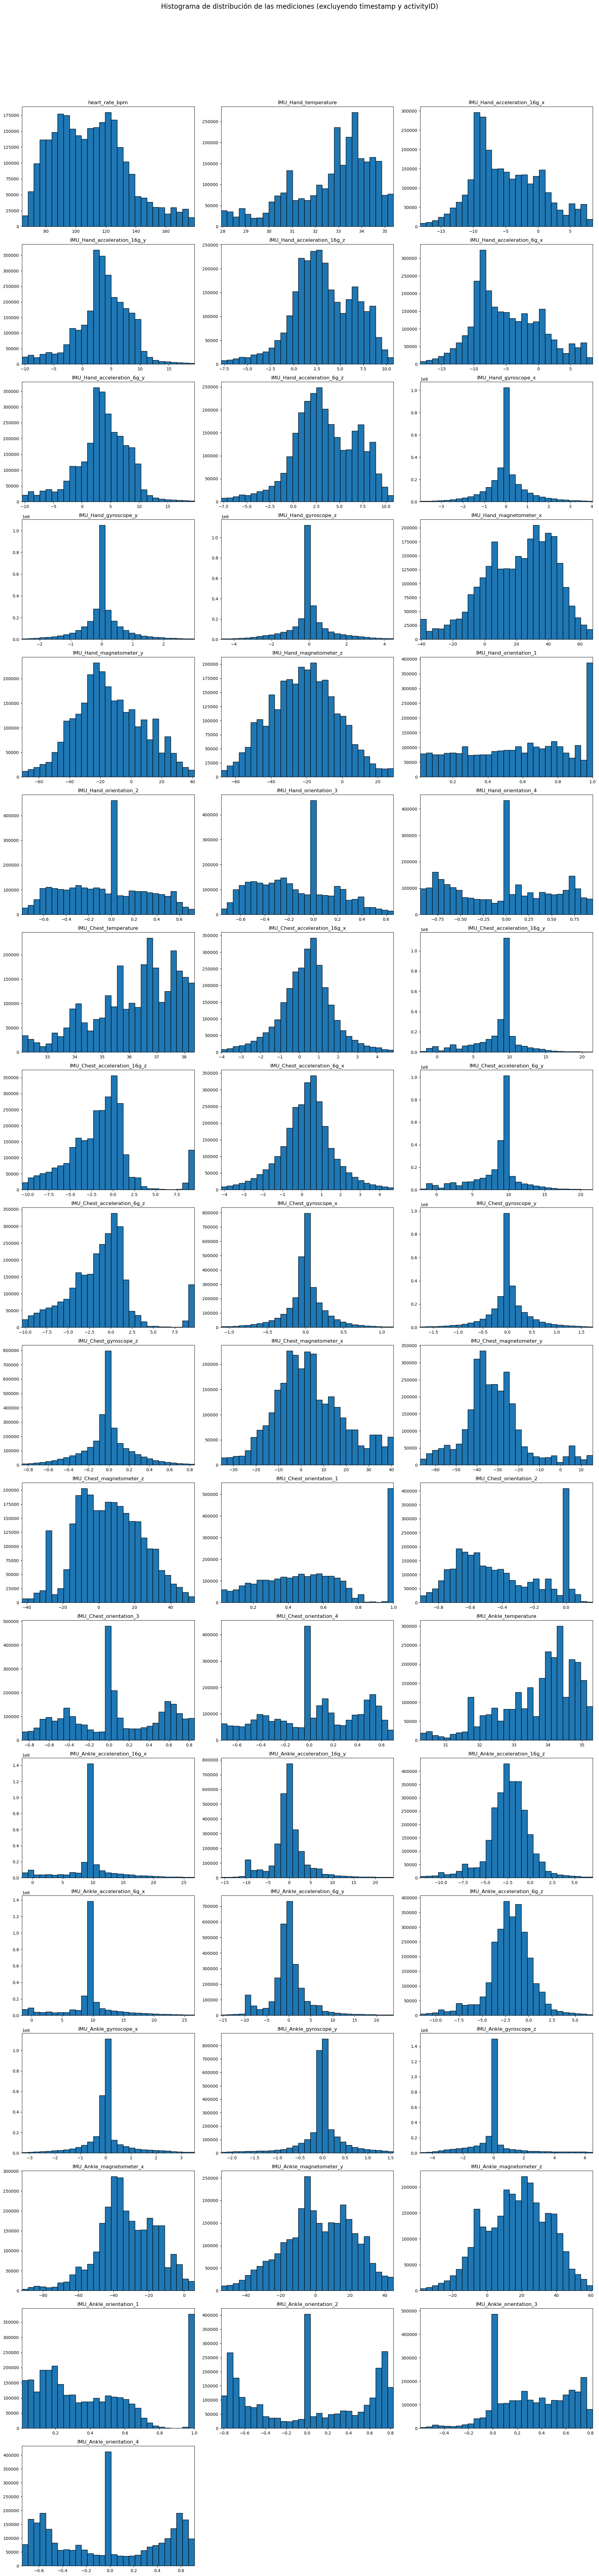

In [44]:
import numpy as np
import math
import matplotlib.pyplot as plt

# Lista de columnas que queremos excluir
excluded_cols = ['timestamp', 'activityID']

# Seleccionamos solo las columnas numéricas y excluimos 'timestamp' y 'activityID'
pamap_numeric = (
    pamap_no_null
    .select_dtypes(include=['number'])
    .drop(columns=excluded_cols, errors='ignore')
)

# Obtenemos la lista de columnas numéricas restantes
columns = pamap_numeric.columns
num_attributes = len(columns)

# Definimos el layout: máximo 3 columnas por fila
cols = 3
rows = math.ceil(num_attributes / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten()  # Para iterar fácilmente

for ax, col in zip(axes, columns):
    data = pamap_numeric[col].dropna()

    # Calculamos percentiles (por ejemplo, 1% y 99%)
    q1 = data.quantile(0.01)
    q99 = data.quantile(0.99)

    # Si el rango de valores en los percentiles es muy pequeño, evitamos errores
    if q1 == q99:
        ax.hist(data, bins=10, edgecolor='black')
        ax.set_title(col)
        ax.set_xlim([q1 - 1, q99 + 1])  # Ajuste mínimo para que no sea un rango vacío
        continue

    # Filtramos datos para el histograma (recortando outliers)
    data_filtered = data[(data >= q1) & (data <= q99)]

    # Generamos bins para ese rango filtrado
    bins = np.linspace(q1, q99, 30)

    # Graficamos solo los datos filtrados
    ax.hist(data_filtered, bins=bins, edgecolor='black')
    ax.set_title(col)

    # Ajustamos el límite de los ejes al rango filtrado
    ax.set_xlim([q1, q99])

# Si sobran ejes (subplots) porque hay menos columnas que subplots, los ocultamos
for ax in axes[num_attributes:]:
    ax.set_visible(False)

plt.suptitle("Histograma de distribución de las mediciones (excluyendo timestamp y activityID)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


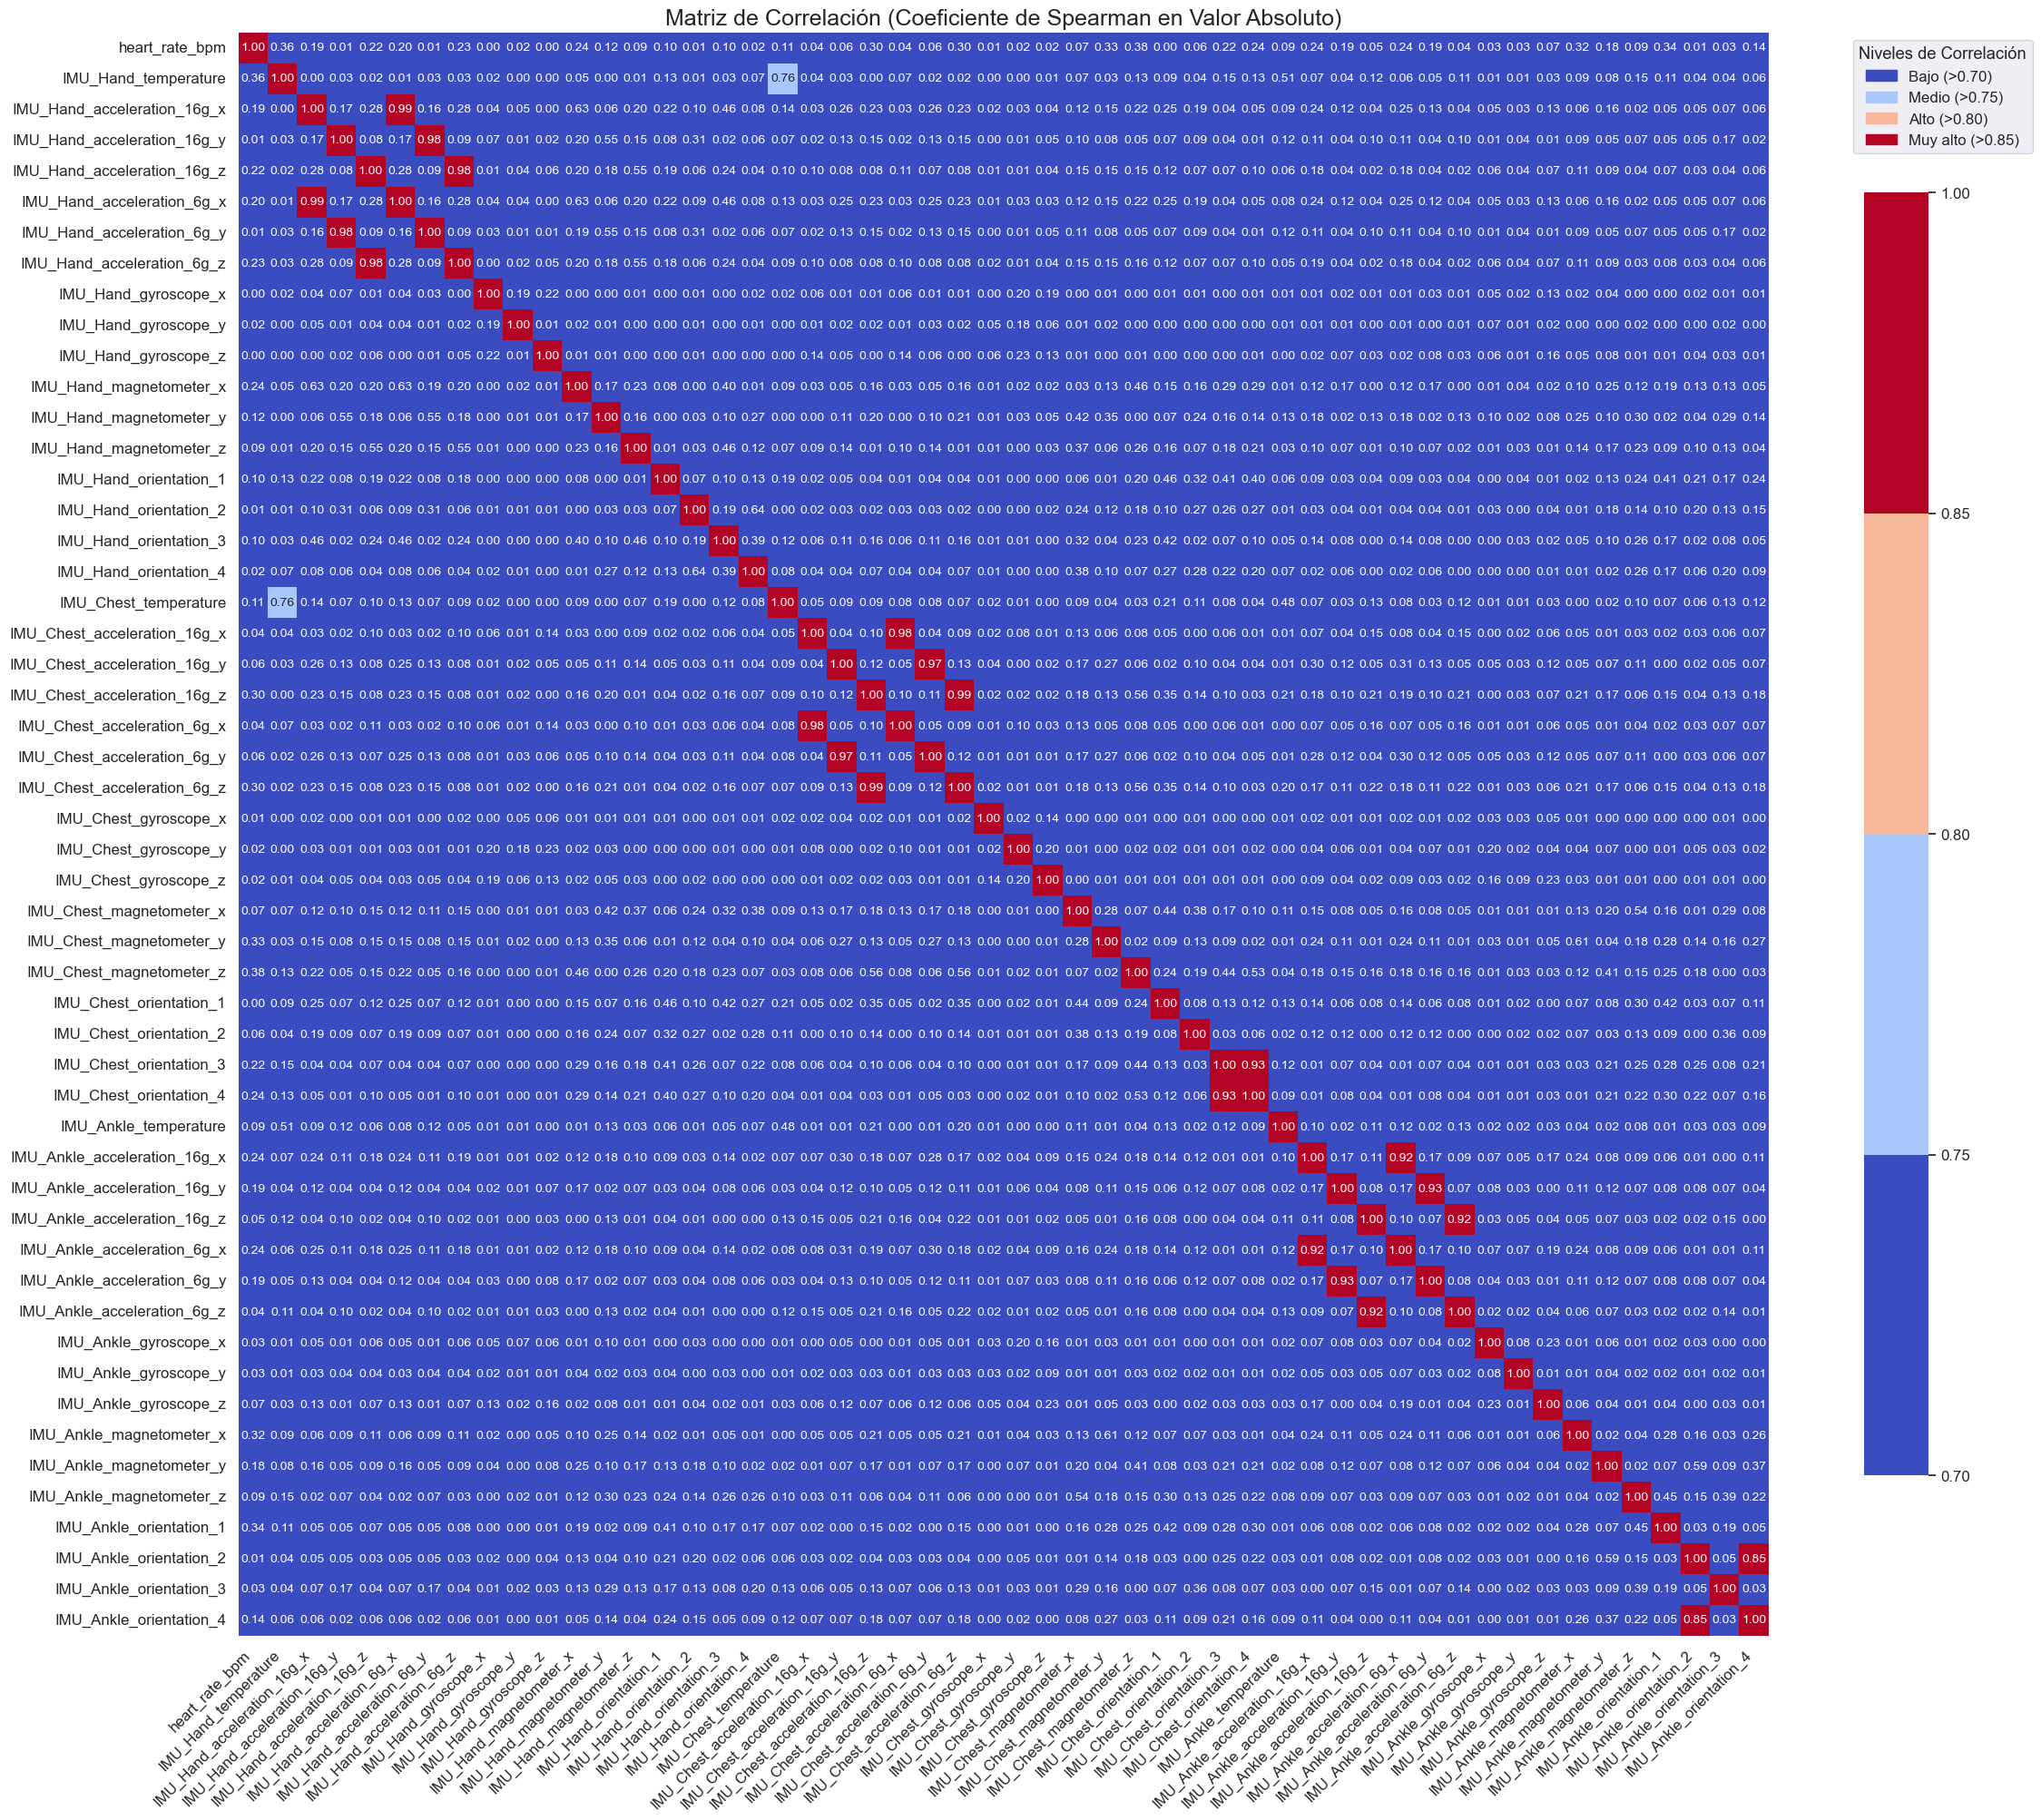

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap
from matplotlib.patches import Patch

# Suponiendo que pamap_corr_matrix es tu matriz de correlación calculada con el método de Spearman

# Calcular la matriz de correlación en términos absolutos
pamap_corr_matrix_abs = pamap_corr_matrix.abs()

# Definir los límites para las categorías de correlación
boundaries = [0.7, 0.75, 0.8, 0.85, 1.0]

# Crear un colormap discreto basado en 'coolwarm' con 4 colores
cmap = LinearSegmentedColormap.from_list(
    'coolwarm_discrete', plt.get_cmap('coolwarm')(np.linspace(0, 1, 4)), 4
)

# Crear una normalización basada en los límites definidos
norm = BoundaryNorm(boundaries, cmap.N, clip=True)

# Definir las categorías y sus colores asociados
categorias = ['Bajo (>0.70)', 'Medio (>0.75)', 'Alto (>0.80)', 'Muy alto (>0.85)']
colores = [cmap(norm(boundaries[i])) for i in range(len(boundaries) - 1)]

# Crear parches de color para la leyenda
patches = [Patch(color=colores[i], label=categorias[i]) for i in range(len(categorias))]

sns.set(font_scale=1.1)
plt.figure(figsize=(24, 20))

# Generar el mapa de calor
sns.heatmap(
    pamap_corr_matrix_abs,
    annot=True,         # Mostrar valores numéricos
    fmt=".2f",          # Formato de 2 decimales
    cmap=cmap,
    norm=norm,
    annot_kws={"size": 10},  # Tamaño de fuente de los valores dentro de las celdas
    square=False,
    cbar_kws={"shrink": 0.8} # Ajusta el tamaño de la barra de color
)

# Rotar etiquetas del eje X
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Ajusta automáticamente los márgenes
plt.tight_layout()

# Agregar la leyenda personalizada
plt.legend(handles=patches, title='Niveles de Correlación', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Matriz de Correlación (Coeficiente de Spearman en Valor Absoluto)', fontsize=18)
plt.show()


Observando la matriz de correlación notamos que hay varias características correlacionadas, pero nos gustaría saber puntualmente cuáles son. A continuación se obtienen las que tengan un índice de correlación superior a 0.8 (alta correlación): 

In [101]:
import pandas as pd

# Suponiendo que pamap_corr_matrix es tu matriz de correlación calculada con el método de Spearman

# Definir los límites y las etiquetas para las categorías de correlación
limites = [0.7, 0.75, 0.8, 0.85]
categorias = ['Bajo', 'Medio', 'Alto', 'Muy alto']

# Inicializar una lista para almacenar los pares de columnas con su categoría de correlación
pares_correlacionados = []

# Iterar sobre la matriz de correlación
for i in range(len(pamap_corr_matrix.columns)):
    for j in range(i + 1, len(pamap_corr_matrix.columns)):
        col1 = pamap_corr_matrix.columns[i]
        col2 = pamap_corr_matrix.columns[j]
        corr_value = abs(pamap_corr_matrix.iloc[i, j])  # Tomar el valor absoluto de la correlación
        
        # Determinar la categoría de correlación
        categoria = None
        for limite, cat in zip(limites[::-1], categorias[::-1]):  # Iterar en orden inverso
            if corr_value > limite:
                categoria = cat
                break
        
        # Si la correlación supera el límite más bajo, agregar a la lista
        if categoria:
            pares_correlacionados.append((col1, col2, corr_value, categoria))

# Mostrar los pares de columnas con su categoría de correlación
for col1, col2, corr_value, categoria in pares_correlacionados:
    print(f"Las columnas '{col1}' y '{col2}' tienen una correlación {categoria} de {corr_value:.2f}")

Las columnas 'IMU_Hand_temperature' y 'IMU_Chest_temperature' tienen una correlación Medio de 0.76
Las columnas 'IMU_Hand_acceleration_16g_x' y 'IMU_Hand_acceleration_6g_x' tienen una correlación Muy alto de 0.99
Las columnas 'IMU_Hand_acceleration_16g_y' y 'IMU_Hand_acceleration_6g_y' tienen una correlación Muy alto de 0.98
Las columnas 'IMU_Hand_acceleration_16g_z' y 'IMU_Hand_acceleration_6g_z' tienen una correlación Muy alto de 0.98
Las columnas 'IMU_Chest_acceleration_16g_x' y 'IMU_Chest_acceleration_6g_x' tienen una correlación Muy alto de 0.98
Las columnas 'IMU_Chest_acceleration_16g_y' y 'IMU_Chest_acceleration_6g_y' tienen una correlación Muy alto de 0.97
Las columnas 'IMU_Chest_acceleration_16g_z' y 'IMU_Chest_acceleration_6g_z' tienen una correlación Muy alto de 0.99
Las columnas 'IMU_Chest_orientation_3' y 'IMU_Chest_orientation_4' tienen una correlación Muy alto de 0.93
Las columnas 'IMU_Ankle_acceleration_16g_x' y 'IMU_Ankle_acceleration_6g_x' tienen una correlación Muy a

La presencia de columnas altamente correlacionadas incrementa la dimensionalidad del conjunto de datos, lo que eleva el costo computacional e introduce redundancias. Esto puede sesgar la clasificación, ya que una misma característica se cuenta varias veces, otorgándole un impacto desproporcionado en comparación con las demás. Es por esto que eliminamos las características correlacionadas. 

In [112]:
pamap_remove_redundant = pamap_data.copy()

columns_to_remove = [
    # Pares IMU_Hand: se eliminan las de 16g para dejar las de 6g
    "IMU_Hand_acceleration_6g_x",
    "IMU_Hand_acceleration_6g_y",
    "IMU_Hand_acceleration_6g_z",
    
    # Pares IMU_Chest: se eliminan las de 16g para dejar las de 6g
    "IMU_Chest_acceleration_16g_x",
    "IMU_Chest_acceleration_16g_y",
    "IMU_Chest_acceleration_16g_z",
    
    # Pares IMU_Ankle: se eliminan las de 16g para las aceleraciones
    "IMU_Ankle_acceleration_6g_x",
    "IMU_Ankle_acceleration_6g_y",
]

pamap_remove_redundant.drop(columns=columns_to_remove, inplace=True)

In [114]:
import pandas as pd

# Suponiendo que 'pamap_no_null' es tu DataFrame original

# Eliminar las columnas 'activityID' y 'timestamp' si existen
pamap_filtered_2 = pamap_remove_redundant.drop(columns=['activityID', 'timestamp'], errors='ignore')

# Seleccionar solo las columnas numéricas restantes
pamap_numeric_2 = pamap_filtered_2.select_dtypes(include=['number'])

# Calcular la matriz de correlación utilizando el método de Spearman
pamap_corr_matrix_2 = pamap_numeric_2.corr(method='spearman')

# Mostrar la matriz de correlación
pamap_corr_matrix_2

,heart_rate_bpm,IMU_Hand_temperature,IMU_Hand_acceleration_16g_x,IMU_Hand_acceleration_16g_y,IMU_Hand_acceleration_16g_z,IMU_Hand_gyroscope_x,IMU_Hand_gyroscope_y,IMU_Hand_gyroscope_z,IMU_Hand_magnetometer_x,IMU_Hand_magnetometer_y,...,IMU_Ankle_gyroscope_x,IMU_Ankle_gyroscope_y,IMU_Ankle_gyroscope_z,IMU_Ankle_magnetometer_x,IMU_Ankle_magnetometer_y,IMU_Ankle_magnetometer_z,IMU_Ankle_orientation_1,IMU_Ankle_orientation_2,IMU_Ankle_orientation_3,IMU_Ankle_orientation_4
heart_rate_bpm,1.000,-0.360,-0.194,0.011,-0.220,-0.004,0.023,0.003,0.243,-0.118,...,-0.029,0.033,-0.065,-0.325,-0.179,-0.094,0.343,0.014,-0.029,0.141
IMU_Hand_temperature,-0.360,1.000,-0.006,-0.028,0.017,-0.015,-0.003,-0.001,-0.050,0.001,...,0.015,-0.012,0.031,0.089,0.079,0.150,-0.114,0.037,0.041,0.062
IMU_Hand_acceleration_16g_x,-0.194,-0.006,1.000,0.170,0.281,0.037,-0.048,0.005,-0.631,-0.059,...,0.053,-0.029,0.132,0.064,0.158,-0.025,-0.048,0.048,-0.073,-0.062
IMU_Hand_acceleration_16g_y,0.011,-0.028,0.170,1.000,-0.079,0.071,0.011,-0.020,-0.198,-0.548,...,0.008,-0.040,-0.014,-0.086,-0.055,0.072,0.049,-0.046,-0.166,-0.019
IMU_Hand_acceleration_16g_z,-0.220,0.017,0.281,-0.079,1.000,-0.005,0.039,-0.059,-0.200,0.181,...,0.057,-0.043,0.073,0.107,0.086,-0.035,-0.074,0.025,-0.041,-0.064
IMU_Hand_gyroscope_x,-0.004,-0.015,0.037,0.071,-0.005,1.000,-0.189,-0.220,-0.003,-0.004,...,0.045,-0.023,0.131,0.023,-0.041,-0.002,-0.004,-0.022,-0.015,-0.008
IMU_Hand_gyroscope_y,0.023,-0.003,-0.048,0.011,0.039,-0.189,1.000,0.007,-0.020,-0.008,...,0.073,0.015,0.021,0.004,-0.004,-0.020,0.000,0.003,-0.021,0.002
IMU_Hand_gyroscope_z,0.003,-0.001,0.005,-0.020,-0.059,-0.220,0.007,1.000,-0.006,-0.009,...,-0.053,-0.009,-0.154,-0.045,0.082,0.013,0.008,0.036,0.025,0.010
IMU_Hand_magnetometer_x,0.243,-0.050,-0.631,-0.198,-0.200,-0.003,-0.020,-0.006,1.000,0.171,...,0.012,-0.041,-0.023,-0.101,-0.248,-0.118,0.187,-0.129,0.126,-0.049
IMU_Hand_magnetometer_y,-0.118,0.001,-0.059,-0.548,0.181,-0.004,-0.008,-0.009,0.171,1.000,...,0.096,-0.021,0.083,0.250,0.097,-0.301,-0.017,-0.038,0.285,-0.135


## 2.9. Gráfica de densidad para los atributos

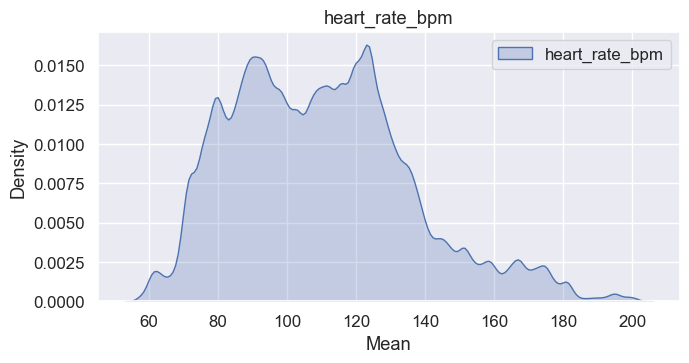

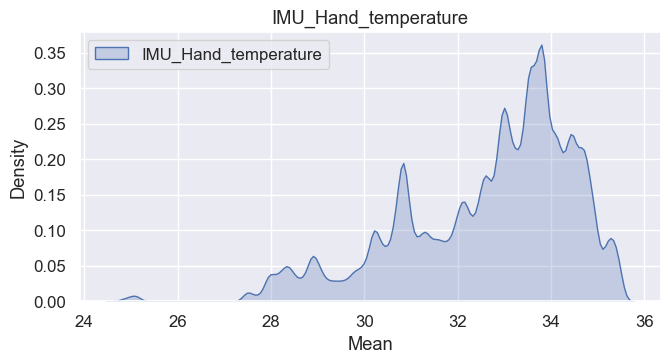

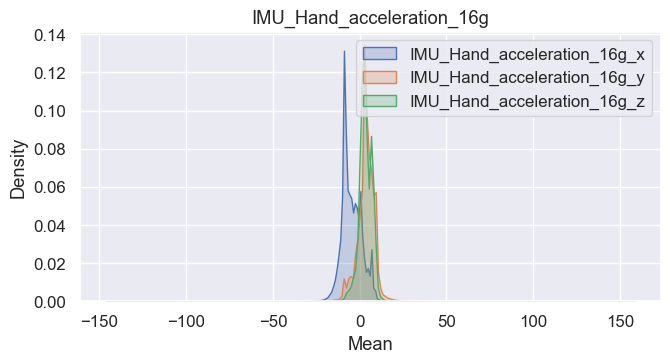

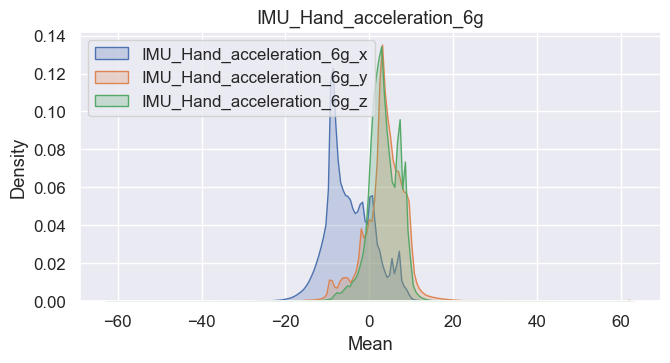

KeyboardInterrupt: 

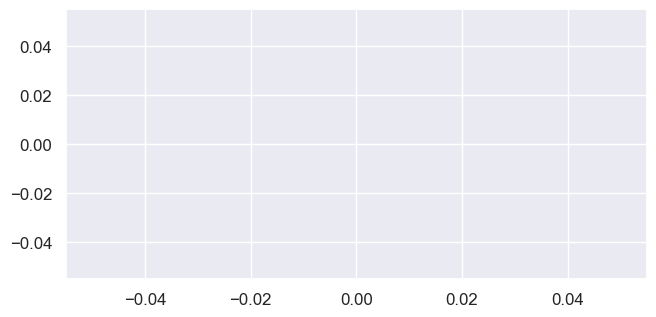

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

# Lista de columnas
columnas = [
    "heart_rate_bpm",
    "IMU_Hand_temperature",
    "IMU_Hand_acceleration_16g_x",
    "IMU_Hand_acceleration_16g_y",
    "IMU_Hand_acceleration_16g_z",
    "IMU_Hand_acceleration_6g_x",
    "IMU_Hand_acceleration_6g_y",
    "IMU_Hand_acceleration_6g_z",
    "IMU_Hand_gyroscope_x",
    "IMU_Hand_gyroscope_y",
    "IMU_Hand_gyroscope_z",
    "IMU_Hand_magnetometer_x",
    "IMU_Hand_magnetometer_y",
    "IMU_Hand_magnetometer_z",
    "IMU_Hand_orientation_1",
    "IMU_Hand_orientation_2",
    "IMU_Hand_orientation_3",
    "IMU_Hand_orientation_4",
    "IMU_Chest_temperature",
    "IMU_Chest_acceleration_16g_x",
    "IMU_Chest_acceleration_16g_y",
    "IMU_Chest_acceleration_16g_z",
    "IMU_Chest_acceleration_6g_x",
    "IMU_Chest_acceleration_6g_y",
    "IMU_Chest_acceleration_6g_z",
    "IMU_Chest_gyroscope_x",
    "IMU_Chest_gyroscope_y",
    "IMU_Chest_gyroscope_z",
    "IMU_Chest_magnetometer_x",
    "IMU_Chest_magnetometer_y",
    "IMU_Chest_magnetometer_z",
    "IMU_Chest_orientation_1",
    "IMU_Chest_orientation_2",
    "IMU_Chest_orientation_3",
    "IMU_Chest_orientation_4",
    "IMU_Ankle_temperature",
    "IMU_Ankle_acceleration_16g_x",
    "IMU_Ankle_acceleration_16g_y",
    "IMU_Ankle_acceleration_16g_z",
    "IMU_Ankle_acceleration_6g_x",
    "IMU_Ankle_acceleration_6g_y",
    "IMU_Ankle_acceleration_6g_z",
    "IMU_Ankle_gyroscope_x",
    "IMU_Ankle_gyroscope_y",
    "IMU_Ankle_gyroscope_z",
    "IMU_Ankle_magnetometer_x",
    "IMU_Ankle_magnetometer_y",
    "IMU_Ankle_magnetometer_z",
    "IMU_Ankle_orientation_1",
    "IMU_Ankle_orientation_2",
    "IMU_Ankle_orientation_3",
    "IMU_Ankle_orientation_4"
]

# Conjunto para llevar el control de las columnas ya graficadas
procesadas = set()

for col in columnas:
    if col in procesadas:
        continue

    # Si la columna contiene "orientation", se agrupan todas las orientaciones del sensor
    if "orientation" in col:
        # Se toma como base el nombre sin el número final, por ejemplo "IMU_Ankle_orientation"
        base = col.rsplit('_', 1)[0]
        # Se obtienen todas las columnas que empiezan con esa base
        group_cols = [c for c in columnas if c.startswith(base)]
        if group_cols:
            plt.figure(figsize=(7.5, 3.5))
            for sensor in sorted(group_cols):
                sns.kdeplot(pamap_no_null[sensor], fill=True, label=sensor)
            plt.xlabel('Mean')
            plt.ylabel('Density')
            plt.title(base)
            plt.legend()
            plt.show()
            procesadas.update(group_cols)
        continue

    # Caso de variables agrupables por eje: _x, _y, _z
    if col.endswith('_x'):
        base = col[:-2]  # Se quita el sufijo "_x"
        col_y = base + '_y'
        col_z = base + '_z'
        if col_y in columnas and col_z in columnas:
            plt.figure(figsize=(7.5, 3.5))
            for sensor in [col, col_y, col_z]:
                sns.kdeplot(pamap_no_null[sensor], fill=True, label=sensor)
            plt.xlabel('Mean')
            plt.ylabel('Density')
            plt.title(base)
            plt.legend()
            plt.show()
            procesadas.update({col, col_y, col_z})
        else:
            plt.figure(figsize=(7.5, 3.5))
            sns.kdeplot(pamap_no_null[col], fill=True, label=col)
            plt.xlabel('Mean')
            plt.ylabel('Density')
            plt.title(col)
            plt.legend()
            plt.show()
            procesadas.add(col)
    elif col.endswith('_y') or col.endswith('_z'):
        plt.figure(figsize=(7.5, 3.5))
        sns.kdeplot(pamap_no_null[col], fill=True, label=col)
        plt.xlabel('Mean')
        plt.ylabel('Density')
        plt.title(col)
        plt.legend()
        plt.show()
        procesadas.add(col)
    else:
        # Para el resto de columnas, se grafica individualmente
        plt.figure(figsize=(7.5, 3.5))
        sns.kdeplot(pamap_no_null[col], fill=True, label=col)
        plt.xlabel('Mean')
        plt.ylabel('Density')
        plt.title(col)
        plt.legend()
        plt.show()
        procesadas.add(col)


KeyboardInterrupt: 

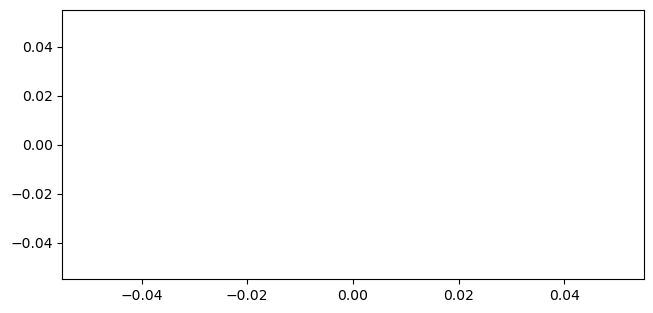

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

# Lista de columnas
columnas = [
    "heart_rate_bpm",
    "IMU_Hand_temperature",
    "IMU_Hand_acceleration_16g_x",
    "IMU_Hand_acceleration_16g_y",
    "IMU_Hand_acceleration_16g_z",
    "IMU_Hand_acceleration_6g_x",
    "IMU_Hand_acceleration_6g_y",
    "IMU_Hand_acceleration_6g_z",
    "IMU_Hand_gyroscope_x",
    "IMU_Hand_gyroscope_y",
    "IMU_Hand_gyroscope_z",
    "IMU_Hand_magnetometer_x",
    "IMU_Hand_magnetometer_y",
    "IMU_Hand_magnetometer_z",
    "IMU_Hand_orientation_1",
    "IMU_Hand_orientation_2",
    "IMU_Hand_orientation_3",
    "IMU_Hand_orientation_4",
    "IMU_Chest_temperature",
    "IMU_Chest_acceleration_16g_x",
    "IMU_Chest_acceleration_16g_y",
    "IMU_Chest_acceleration_16g_z",
    "IMU_Chest_acceleration_6g_x",
    "IMU_Chest_acceleration_6g_y",
    "IMU_Chest_acceleration_6g_z",
    "IMU_Chest_gyroscope_x",
    "IMU_Chest_gyroscope_y",
    "IMU_Chest_gyroscope_z",
    "IMU_Chest_magnetometer_x",
    "IMU_Chest_magnetometer_y",
    "IMU_Chest_magnetometer_z",
    "IMU_Chest_orientation_1",
    "IMU_Chest_orientation_2",
    "IMU_Chest_orientation_3",
    "IMU_Chest_orientation_4",
    "IMU_Ankle_temperature",
    "IMU_Ankle_acceleration_16g_x",
    "IMU_Ankle_acceleration_16g_y",
    "IMU_Ankle_acceleration_16g_z",
    "IMU_Ankle_acceleration_6g_x",
    "IMU_Ankle_acceleration_6g_y",
    "IMU_Ankle_acceleration_6g_z",
    "IMU_Ankle_gyroscope_x",
    "IMU_Ankle_gyroscope_y",
    "IMU_Ankle_gyroscope_z",
    "IMU_Ankle_magnetometer_x",
    "IMU_Ankle_magnetometer_y",
    "IMU_Ankle_magnetometer_z",
    "IMU_Ankle_orientation_1",
    "IMU_Ankle_orientation_2",
    "IMU_Ankle_orientation_3",
    "IMU_Ankle_orientation_4"
]

# Conjunto para llevar el control de las columnas ya graficadas
procesadas = set()

for col in columnas:
    if col in procesadas:
        continue

    # Si la columna contiene "orientation", se agrupan todas las orientaciones del sensor
    if "orientation" in col:
        # Se toma como base el nombre sin el número final, por ejemplo "IMU_Ankle_orientation"
        base = col.rsplit('_', 1)[0]
        # Se obtienen todas las columnas que empiezan con esa base
        group_cols = [c for c in columnas if c.startswith(base)]
        if group_cols:
            plt.figure(figsize=(7.5, 3.5))
            for sensor in sorted(group_cols):
                sns.kdeplot(pamap_no_null[sensor], fill=True, label=sensor)
            plt.xlabel('Mean')
            plt.ylabel('Density')
            plt.title(base)
            plt.legend()
            plt.show()
            procesadas.update(group_cols)
        continue

    # Caso de variables agrupables por eje: _x, _y, _z
    if col.endswith('_x'):
        base = col[:-2]  # Se quita el sufijo "_x"
        col_y = base + '_y'
        col_z = base + '_z'
        if col_y in columnas and col_z in columnas:
            plt.figure(figsize=(7.5, 3.5))
            for sensor in [col, col_y, col_z]:
                sns.kdeplot(pamap_no_null[sensor], fill=True, label=sensor)
            plt.xlabel('Mean')
            plt.ylabel('Density')
            plt.title(base)
            plt.legend()
            plt.show()
            procesadas.update({col, col_y, col_z})
        else:
            plt.figure(figsize=(7.5, 3.5))
            sns.kdeplot(pamap_no_null[col], fill=True, label=col)
            plt.xlabel('Mean')
            plt.ylabel('Density')
            plt.title(col)
            plt.legend()
            plt.show()
            procesadas.add(col)
    elif col.endswith('_y') or col.endswith('_z'):
        plt.figure(figsize=(7.5, 3.5))
        sns.kdeplot(pamap_no_null[col], fill=True, label=col)
        plt.xlabel('Mean')
        plt.ylabel('Density')
        plt.title(col)
        plt.legend()
        plt.show()
        procesadas.add(col)
    else:
        # Para el resto de columnas, se grafica individualmente
        plt.figure(figsize=(7.5, 3.5))
        sns.kdeplot(pamap_no_null[col], fill=True, label=col)
        plt.xlabel('Mean')
        plt.ylabel('Density')
        plt.title(col)
        plt.legend()
        plt.show()
        procesadas.add(col)


De las gráficas anteriores obtenemos que se presentan muchos valores atípicos, estos afectan la distribución de nuestros datos, por lo que vamos a filtrar aquellos que se alejen más de 3 desviaciones estándar de la media.

## 2.10. Gráfica de caja y bigotes para la distribución de los atributos. 

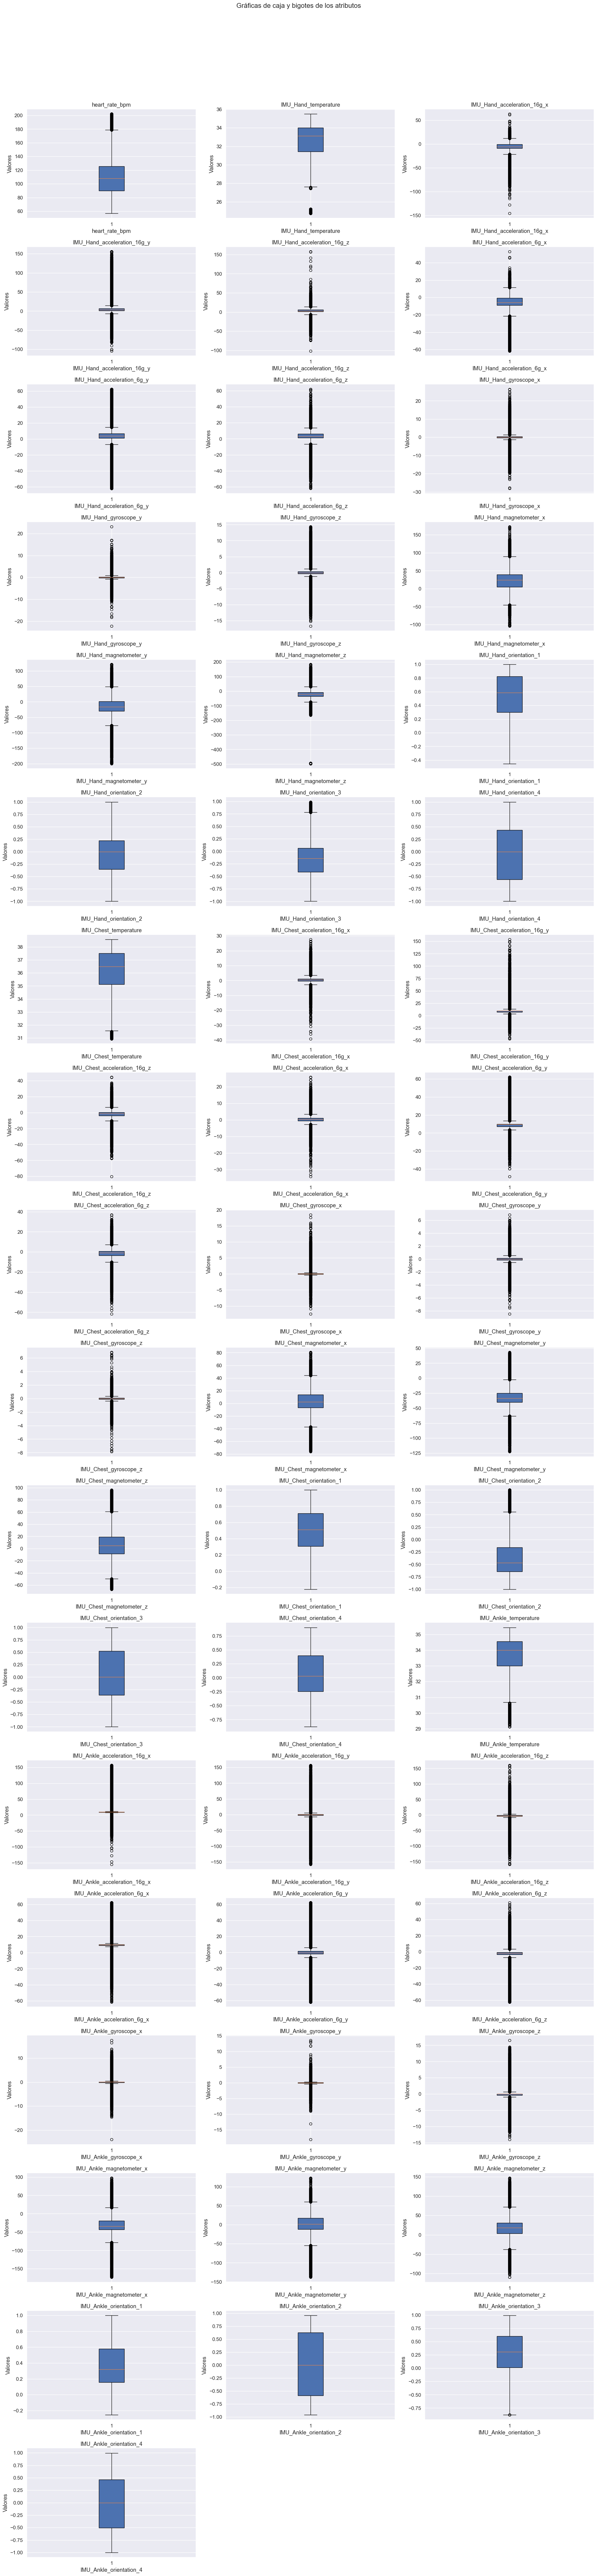

In [89]:
import matplotlib.pyplot as plt
import pandas as pd
import math

columnas_seleccionadas = [
    'heart_rate_bpm',
    'IMU_Hand_temperature',
    'IMU_Hand_acceleration_16g_x',
    'IMU_Hand_acceleration_16g_y',
    'IMU_Hand_acceleration_16g_z',
    'IMU_Hand_acceleration_6g_x',
    'IMU_Hand_acceleration_6g_y',
    'IMU_Hand_acceleration_6g_z',
    'IMU_Hand_gyroscope_x',
    'IMU_Hand_gyroscope_y',
    'IMU_Hand_gyroscope_z',
    'IMU_Hand_magnetometer_x',
    'IMU_Hand_magnetometer_y',
    'IMU_Hand_magnetometer_z',
    'IMU_Hand_orientation_1',
    'IMU_Hand_orientation_2',
    'IMU_Hand_orientation_3',
    'IMU_Hand_orientation_4',
    'IMU_Chest_temperature',
    'IMU_Chest_acceleration_16g_x',
    'IMU_Chest_acceleration_16g_y',
    'IMU_Chest_acceleration_16g_z',
    'IMU_Chest_acceleration_6g_x',
    'IMU_Chest_acceleration_6g_y',
    'IMU_Chest_acceleration_6g_z',
    'IMU_Chest_gyroscope_x',
    'IMU_Chest_gyroscope_y',
    'IMU_Chest_gyroscope_z',
    'IMU_Chest_magnetometer_x',
    'IMU_Chest_magnetometer_y',
    'IMU_Chest_magnetometer_z',
    'IMU_Chest_orientation_1',
    'IMU_Chest_orientation_2',
    'IMU_Chest_orientation_3',
    'IMU_Chest_orientation_4',
    'IMU_Ankle_temperature',
    'IMU_Ankle_acceleration_16g_x',
    'IMU_Ankle_acceleration_16g_y',
    'IMU_Ankle_acceleration_16g_z',
    'IMU_Ankle_acceleration_6g_x',
    'IMU_Ankle_acceleration_6g_y',
    'IMU_Ankle_acceleration_6g_z',
    'IMU_Ankle_gyroscope_x',
    'IMU_Ankle_gyroscope_y',
    'IMU_Ankle_gyroscope_z',
    'IMU_Ankle_magnetometer_x',
    'IMU_Ankle_magnetometer_y',
    'IMU_Ankle_magnetometer_z',
    'IMU_Ankle_orientation_1',
    'IMU_Ankle_orientation_2',
    'IMU_Ankle_orientation_3',
    'IMU_Ankle_orientation_4'
]

df_numeric = pamap_no_null[columnas_seleccionadas]

num_attributes = df_numeric.shape[1]

cols = 3
rows = math.ceil(num_attributes / cols)

plt.figure(figsize=(20, 5 * rows))

for i, col in enumerate(df_numeric.columns):
    ax = plt.subplot(rows, cols, i + 1)
    ax.boxplot(df_numeric[col].dropna(), vert=True, patch_artist=True)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Valores")

plt.suptitle("Gráficas de caja y bigotes de los atributos", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

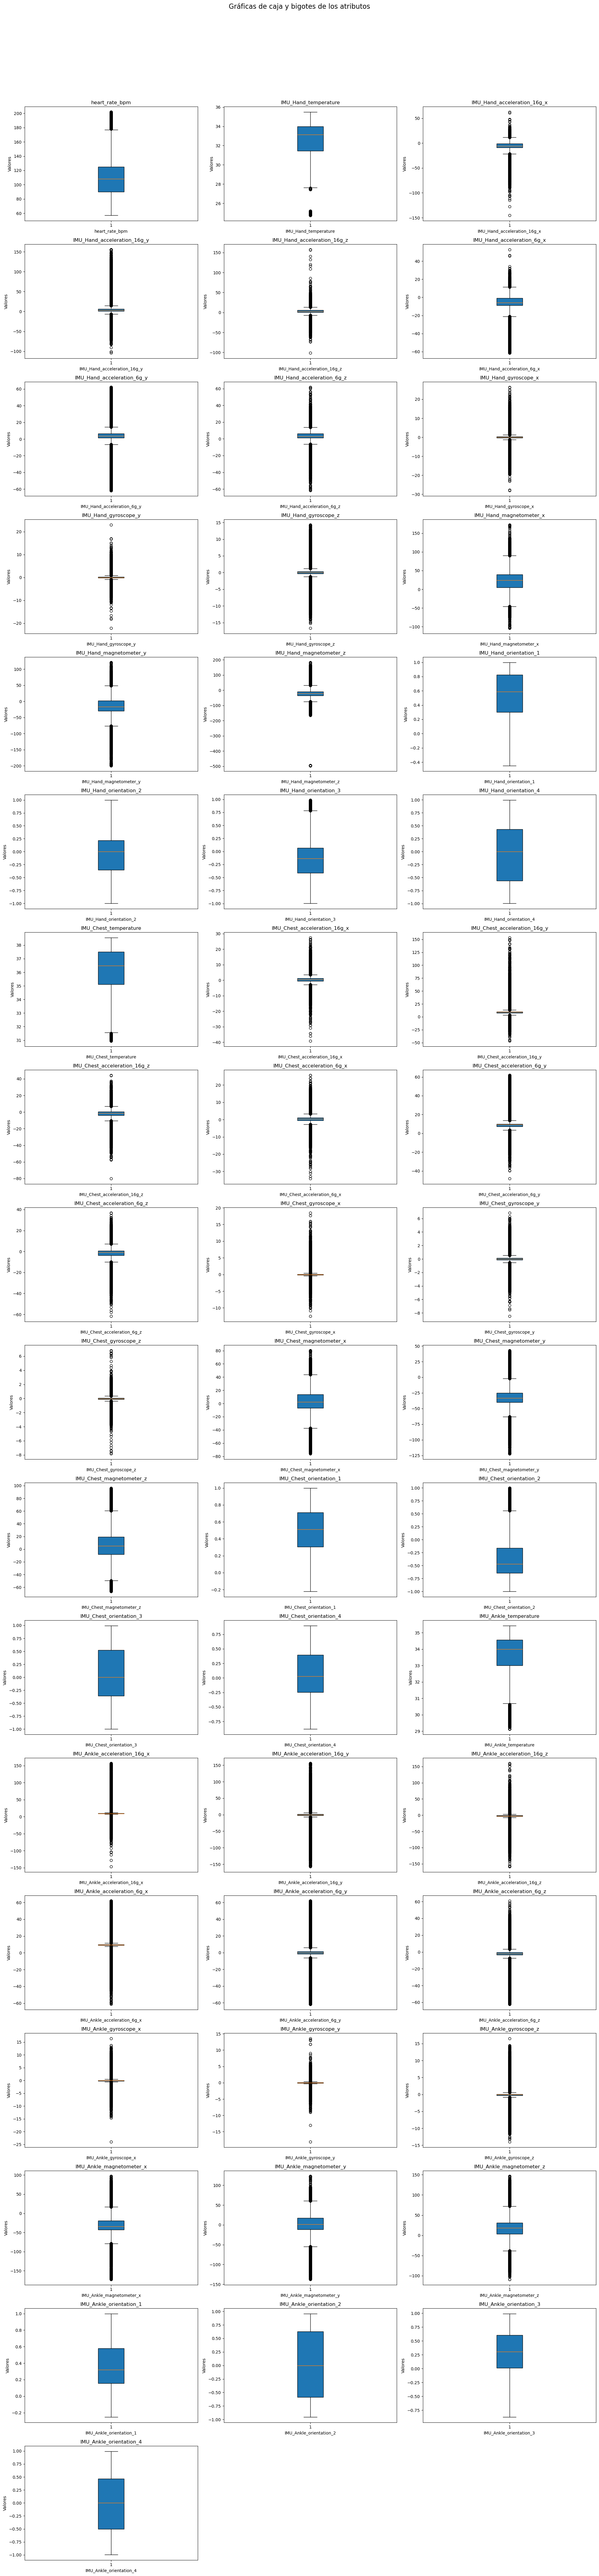

In [102]:
import matplotlib.pyplot as plt
import pandas as pd
import math

columnas_seleccionadas = [
    'heart_rate_bpm',
    'IMU_Hand_temperature',
    'IMU_Hand_acceleration_16g_x',
    'IMU_Hand_acceleration_16g_y',
    'IMU_Hand_acceleration_16g_z',
    'IMU_Hand_acceleration_6g_x',
    'IMU_Hand_acceleration_6g_y',
    'IMU_Hand_acceleration_6g_z',
    'IMU_Hand_gyroscope_x',
    'IMU_Hand_gyroscope_y',
    'IMU_Hand_gyroscope_z',
    'IMU_Hand_magnetometer_x',
    'IMU_Hand_magnetometer_y',
    'IMU_Hand_magnetometer_z',
    'IMU_Hand_orientation_1',
    'IMU_Hand_orientation_2',
    'IMU_Hand_orientation_3',
    'IMU_Hand_orientation_4',
    'IMU_Chest_temperature',
    'IMU_Chest_acceleration_16g_x',
    'IMU_Chest_acceleration_16g_y',
    'IMU_Chest_acceleration_16g_z',
    'IMU_Chest_acceleration_6g_x',
    'IMU_Chest_acceleration_6g_y',
    'IMU_Chest_acceleration_6g_z',
    'IMU_Chest_gyroscope_x',
    'IMU_Chest_gyroscope_y',
    'IMU_Chest_gyroscope_z',
    'IMU_Chest_magnetometer_x',
    'IMU_Chest_magnetometer_y',
    'IMU_Chest_magnetometer_z',
    'IMU_Chest_orientation_1',
    'IMU_Chest_orientation_2',
    'IMU_Chest_orientation_3',
    'IMU_Chest_orientation_4',
    'IMU_Ankle_temperature',
    'IMU_Ankle_acceleration_16g_x',
    'IMU_Ankle_acceleration_16g_y',
    'IMU_Ankle_acceleration_16g_z',
    'IMU_Ankle_acceleration_6g_x',
    'IMU_Ankle_acceleration_6g_y',
    'IMU_Ankle_acceleration_6g_z',
    'IMU_Ankle_gyroscope_x',
    'IMU_Ankle_gyroscope_y',
    'IMU_Ankle_gyroscope_z',
    'IMU_Ankle_magnetometer_x',
    'IMU_Ankle_magnetometer_y',
    'IMU_Ankle_magnetometer_z',
    'IMU_Ankle_orientation_1',
    'IMU_Ankle_orientation_2',
    'IMU_Ankle_orientation_3',
    'IMU_Ankle_orientation_4'
]

df_numeric = pamap_no_null[columnas_seleccionadas]

num_attributes = df_numeric.shape[1]

cols = 3
rows = math.ceil(num_attributes / cols)

plt.figure(figsize=(20, 5 * rows))

for i, col in enumerate(df_numeric.columns):
    ax = plt.subplot(rows, cols, i + 1)
    ax.boxplot(df_numeric[col].dropna(), vert=True, patch_artist=True)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Valores")

plt.suptitle("Gráficas de caja y bigotes de los atributos", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [107]:
import pandas as pd

# Suponiendo que pamap_corr_matrix es tu matriz de correlación calculada con el método de Spearman

# Definir los límites y las etiquetas para las categorías de correlación
limites = [0.7, 0.75, 0.8, 0.85]
categorias = ['Bajo', 'Medio', 'Alto', 'Muy alto']

# Inicializar una lista para almacenar los pares de columnas con su categoría de correlación
pares_correlacionados = []
corr_matrix = pamap_corr_matrix_2
# Iterar sobre la matriz de correlación
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        corr_value = abs(corr_matrix.iloc[i, j])  # Tomar el valor absoluto de la correlación
        
        # Determinar la categoría de correlación
        categoria = None
        for limite, cat in zip(limites[::-1], categorias[::-1]):  # Iterar en orden inverso
            if corr_value > limite:
                categoria = cat
                break
        
        # Si la correlación supera el límite más bajo, agregar a la lista
        if categoria:
            pares_correlacionados.append((col1, col2, corr_value, categoria))

# Mostrar los pares de columnas con su categoría de correlación
for col1, col2, corr_value, categoria in pares_correlacionados:
    print(f"Las columnas '{col1}' y '{col2}' tienen una correlación {categoria} de {corr_value:.2f}")

TypeError: bad operand type for abs(): 'str'

## 2.11. Matriz de correlación de los atributos

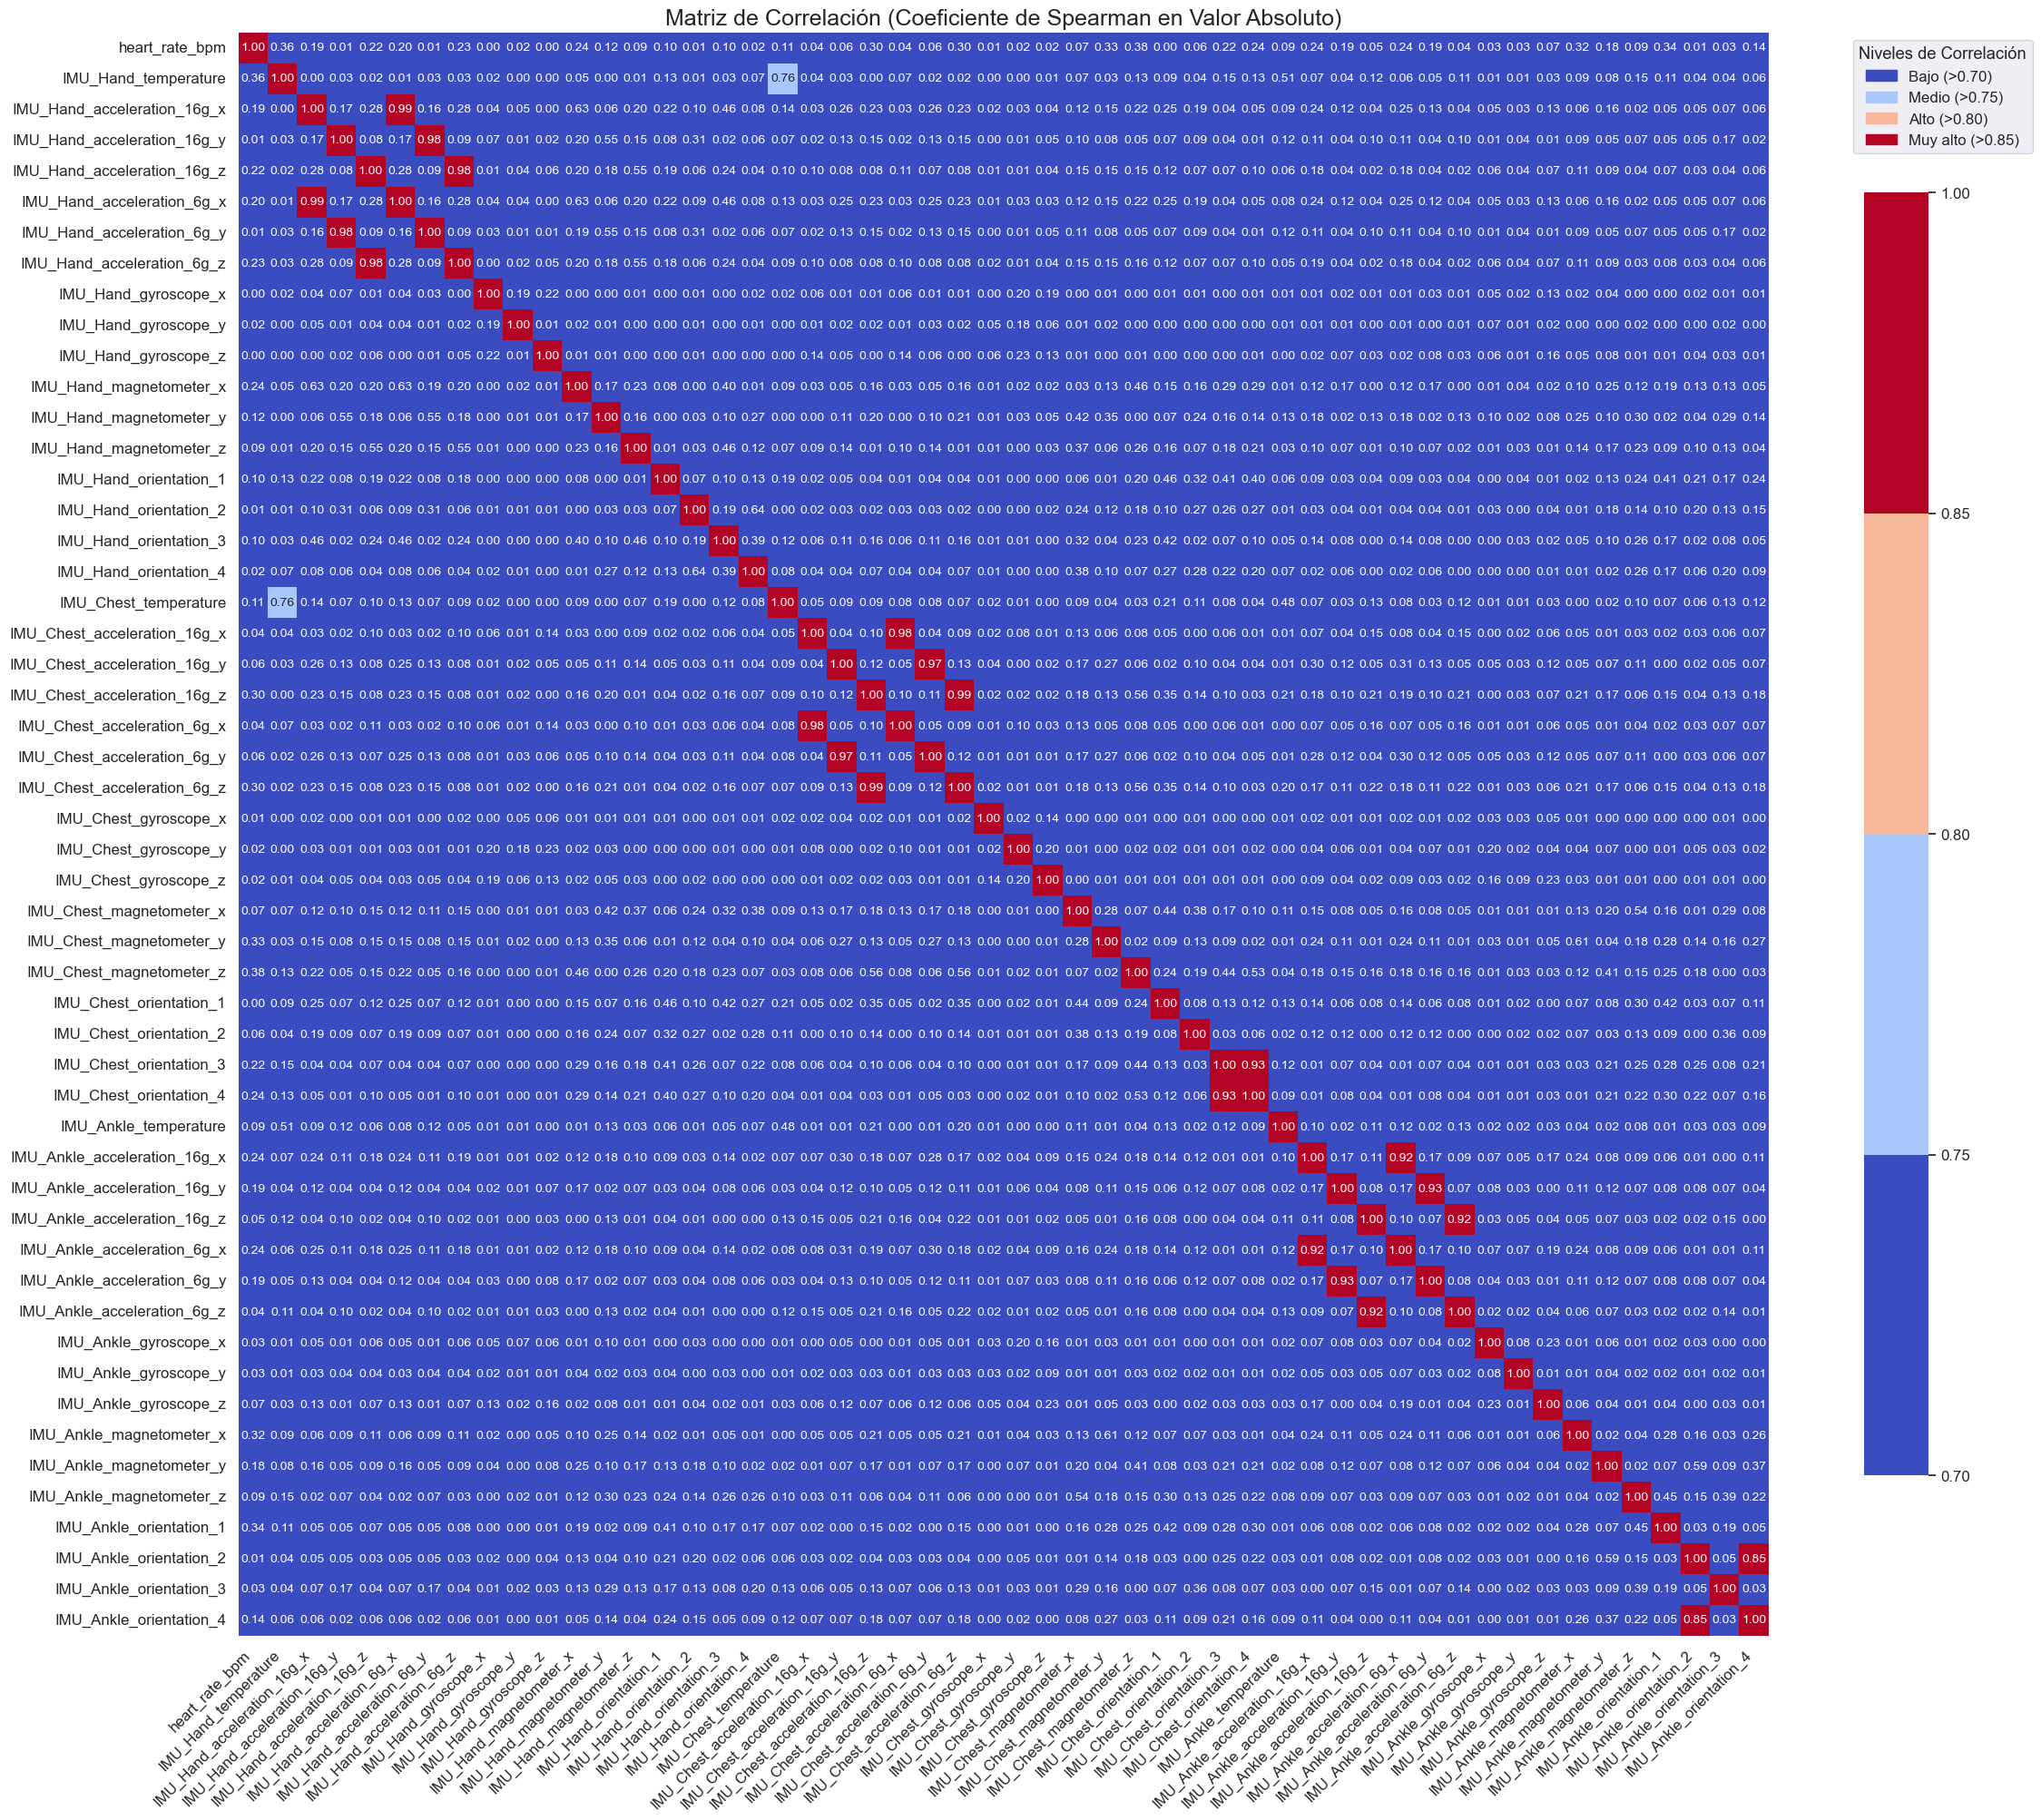

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap
from matplotlib.patches import Patch

# Suponiendo que pamap_corr_matrix es tu matriz de correlación calculada con el método de Spearman

# Calcular la matriz de correlación en términos absolutos
pamap_corr_matrix_abs = pamap_corr_matrix.abs()

# Definir los límites para las categorías de correlación
boundaries = [0.7, 0.75, 0.8, 0.85, 1.0]

# Crear un colormap discreto basado en 'coolwarm' con 4 colores
cmap = LinearSegmentedColormap.from_list(
    'coolwarm_discrete', plt.get_cmap('coolwarm')(np.linspace(0, 1, 4)), 4
)

# Crear una normalización basada en los límites definidos
norm = BoundaryNorm(boundaries, cmap.N, clip=True)

# Definir las categorías y sus colores asociados
categorias = ['Bajo (>0.70)', 'Medio (>0.75)', 'Alto (>0.80)', 'Muy alto (>0.85)']
colores = [cmap(norm(boundaries[i])) for i in range(len(boundaries) - 1)]

# Crear parches de color para la leyenda
patches = [Patch(color=colores[i], label=categorias[i]) for i in range(len(categorias))]

sns.set(font_scale=1.1)
plt.figure(figsize=(24, 20))

# Generar el mapa de calor
sns.heatmap(
    pamap_corr_matrix_abs,
    annot=True,         # Mostrar valores numéricos
    fmt=".2f",          # Formato de 2 decimales
    cmap=cmap,
    norm=norm,
    annot_kws={"size": 10},  # Tamaño de fuente de los valores dentro de las celdas
    square=False,
    cbar_kws={"shrink": 0.8} # Ajusta el tamaño de la barra de color
)

# Rotar etiquetas del eje X
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Ajusta automáticamente los márgenes
plt.tight_layout()

# Agregar la leyenda personalizada
plt.legend(handles=patches, title='Niveles de Correlación', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Matriz de Correlación (Coeficiente de Spearman en Valor Absoluto)', fontsize=18)
plt.show()


## 2.11. Tratando los datos

### 2.11.1. Columnas correlacionadas

### 2.11.2. Valores atípicos